## **Финальный проект по дисциплине "Практикум по работе с данными"**

Март, 2026 г

**Команда 2:**



1.   Сальникова Дарья
2.   Скворцова Екатерина


1.   Венгер Диана
2.   Куркова Арина

1.   Щенникова Полина
2.   Никитин Артем


*Описание первой части нашего проекта:*


**Выбранный рынок:** IT-сектор China (Разработка программного обеспечения)


В рамках данного исследования используются данные по публичным компаниям ИТ-сектора китайского фондового рынка, выгруженные из профессионального информационного терминала Wind.

Выбор Китая и отраслевого подхода обусловлен большим количеством листинговых компаний и высокой экономической значимостью сектора информационных технологий. По нашему заданию были выгружены биржевым данные, данные по финотчетности (использовалась та же выборка компаний), новостные данные, а также данные по капитализации

Дополнительно наша команда имеет теорию, что мы не можем утверждать влиение ROE компании на цену её акции за тот же период, потому что инвестор еще не обладает этой информацией и мы приходит к проблеме мультиколлениарности. Поэтому для того чтобы понять влияет ли известный показатель ROE (за предыдущий год) как фактор принятия решения инвестора о покупке акции и соответсвенно прямо положительным показателем на цену бумаг.

Перед выполнением проекта загрузим необходимые бибилиотеки:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt, dates
import statsmodels.api as sm
from tqdm import tqdm
import glob
import statsmodels.formula.api as smf
import seaborn as sns
import warnings
import statsmodels.api as sm
warnings.filterwarnings("ignore")
# отключаем экспоненциальную запись для всех чисел
pd.set_option('display.float_format', '{:.4f}'.format)



# Part 1 (30%)

Open two MS Excel files (CSV or xlsx format) previously downloaded from Wind for the chosen country market. One file should contain stock prices, and the second should contain any data from the financial report (ROE, revenue, etc.). Set up dates as an index.

**Hint: pd.read_excel(index_col=0)**

In [ ]:

#загружаем данные по фин отчетности
fin_report = pd.read_excel('/content/df_panel_reduced.xlsx')
fin_report.head()

,company,year,Accounts and Notes Receivable(CNY),Accounts and notes payable(CNY),Aggregate Assets(CNY),Aggregation of current assets(CNY),Aggregation of current liabilities(CNY),Aggregation of non-current assets(CNY),Cash and Cash Equivalents(CNY),Comprehensive income available to common shareholders(CNY),...,Total Equity(CNY),Total Op Rev(CNY),Total Receivables(CNY),Total liabilities and shareholders' equity(CNY),Total liabilities(CNY),Total non-current liabilities(CNY),Total operatinG expenses(CNY),Trading financial assets(CNY),Treasury Stock(CNY),Unusual items(CNY)
0,360 SECURITY TECHNOLOGY INC.,2020,1952649000.0000,2145230000.0000,44261773000.0000,30442063000.0000,7237698000.0000,13819710000.0000,5792372000.0000,3637493000.0000,...,36757512000.0000,11569725000.0000,2502301000.0000,44261773000.0000,7504261000.0000,266563000.0000,9802681000.0000,22590000.0000,NaN,49817000.0000
1,360 SECURITY TECHNOLOGY INC.,2021,2276871000.0000,2141734000.0000,42039484000.0000,26047851000.0000,6458037000.0000,15991633000.0000,2969994000.0000,-1251345000.0000,...,34959636000.0000,10811254000.0000,2698285000.0000,42039484000.0000,7079848000.0000,621811000.0000,11180088000.0000,2636089000.0000,537185000.0000,179347000.0000
2,360 SECURITY TECHNOLOGY INC.,2022,1768834000.0000,2205479000.0000,38615763000.0000,26380250000.0000,5658609000.0000,12235513000.0000,6042765000.0000,-1680249000.0000,...,31677793000.0000,9442174000.0000,2045178000.0000,38615763000.0000,6937970000.0000,1279361000.0000,11157050000.0000,503980000.0000,1499998000.0000,-58187000.0000
3,360 SECURITY TECHNOLOGY INC.,2023,1503932000.0000,2166637000.0000,40168367000.0000,29473275000.0000,6949712000.0000,10695092000.0000,11140167000.0000,-369687000.0000,...,31850619000.0000,8975551000.0000,1817689000.0000,40168367000.0000,8317748000.0000,1368036000.0000,9495693000.0000,733691000.0000,1499998000.0000,250362000.0000
4,360 SECURITY TECHNOLOGY INC.,2024,1231198000.0000,1786862000.0000,38256187000.0000,26666381000.0000,6511410000.0000,11589806000.0000,3436417000.0000,-1153224000.0000,...,30135363000.0000,7870205000.0000,1466727000.0000,38256187000.0000,8120824000.0000,1609414000.0000,8808924000.0000,803677000.0000,1499998000.0000,-300165000.0000


In [ ]:
#для нашего задания мы решили взять показатель ROE, возврат на капитал, для оценки речресии с ценами акций
#мы выгружали данные по китайским стандартам финансовой отчетности и за чистую прибыль мы взяли показатель Net Profit from Going Concern(CNY) (чистая прибыль от продолжающейся деятельности)
fin_report['ROE_total'] = fin_report['Net Profit from Going Concern(CNY)'] / fin_report['Total Equity(CNY)']
print(fin_report['ROE_total'])

0       0.0792
1       0.0258
2      -0.0696
3      -0.0155
4      -0.0363
         ...  
1483    0.0725
1484   -0.0862
1485    0.0465
1486    0.0884
1487    0.0371
Name: ROE_total, Length: 1488, dtype: float64


In [ ]:
#после получения показателя ROE сформируем новый дата фрейм для дальнейшей работы с 3 столбцами: имя компании (как в файле с ценами акций), год, показатель ROE
roe = pd.DataFrame()
roe[['Short Name'	, 'Year', 'ROE_total']] = fin_report[['company', 'year', 'ROE_total']]
roe.head()

,Short Name,Year,ROE_total
0,360 SECURITY TECHNOLOGY INC.,2020,0.0792
1,360 SECURITY TECHNOLOGY INC.,2021,0.0258
2,360 SECURITY TECHNOLOGY INC.,2022,-0.0696
3,360 SECURITY TECHNOLOGY INC.,2023,-0.0155
4,360 SECURITY TECHNOLOGY INC.,2024,-0.0363


In [ ]:
#проверяем на наличие пропущенных значений
print(roe.isnull().sum())
print(roe[roe.isnull().any(axis=1)].head(10))

Short Name    0
Year          0
ROE_total     1
dtype: int64
    Short Name  Year  ROE_total
623      IN-TO  2020        NaN


In [ ]:
#а также на то есть ли компании у которых отсуствуют года с 2020 по 2024 год
print(roe.groupby('Short Name')['Year'].apply(lambda x: {2020,2021,2022,2023,2024} - set(x)).loc[lambda x: x.astype(bool)])

Short Name
CSG DIGITAL POWER GRID RESEARCH INSTITUTE    {2020, 2021}
Name: Year, dtype: object


In [ ]:
#у нас есть пропущенные значения у компании IN-TO и не хватает годов у CSG DIGITAL POWER GRID RESEARCH INSTITUTE ввиду этого мы ужаляем эти компании чтобы не было проблем с построением или отклонением по регрессии
companies_to_remove = ['CSG DIGITAL POWER GRID RESEARCH INSTITUTE','IN-TO' ]

# Удаляем строки с этими компаниями
roe_clean = roe[~roe['Short Name'].isin(companies_to_remove)].copy()


In [ ]:
#проверяем наш датафрейм еще раз
print(roe_clean.isnull().sum())
print(roe_clean[roe_clean.isnull().any(axis=1)].head(10))
print(roe_clean.groupby('Short Name')['Year'].apply(lambda x: {2020,2021,2022,2023,2024} - set(x)).loc[lambda x: x.astype(bool)])
#пропущенных значений и годов не наблюдается
roe_clean.head()

Short Name    0
Year          0
ROE_total     0
dtype: int64
Empty DataFrame
Columns: [Short Name, Year, ROE_total]
Index: []
Series([], Name: Year, dtype: object)


,Short Name,Year,ROE_total
0,360 SECURITY TECHNOLOGY INC.,2020,0.0792
1,360 SECURITY TECHNOLOGY INC.,2021,0.0258
2,360 SECURITY TECHNOLOGY INC.,2022,-0.0696
3,360 SECURITY TECHNOLOGY INC.,2023,-0.0155
4,360 SECURITY TECHNOLOGY INC.,2024,-0.0363


In [ ]:
#чтобы сделать потом общий дата фрейм сделаем наш столбец с годами индексом датафрейма, при этом если мы подразумеваем что цена акции зависит он нашего показателя
#(если же мы будем сравнивать данные ROE по году с дохдоностью по этому же году, учитывая что инвесторы не могут смотеть на этот показатель, то может возникнуть проблма эндегенности и зависимость напрямую будет не от этой переменной, а от других внешних факторов которые не включены в модель)
#то есть инвесторы смотрят и оценивают нашу компанию по данным предыдущего года и нам надо сделать так чтобы индексы были соспоставимы у этой переменной и переменной с ценами акций
#поэтому к этой переменной в столбце с годами мы добавляем +1 чтобы создать общий дата фрейм впоследствии
roe_clean['Year'] = roe_clean['Year'].astype(int)
roe_clean['Year'] = roe_clean['Year'] + 1
roe_clean = roe_clean.set_index('Year')
roe_clean.head()

,Short Name,ROE_total
Year,,
2021,360 SECURITY TECHNOLOGY INC.,0.0792
2022,360 SECURITY TECHNOLOGY INC.,0.0258
2023,360 SECURITY TECHNOLOGY INC.,-0.0696
2024,360 SECURITY TECHNOLOGY INC.,-0.0155
2025,360 SECURITY TECHNOLOGY INC.,-0.0363


In [ ]:
#подготавлияваем датафрейм для 2 временных рядов: названия столбцов это названия компаний + подстолбцы 1) ROE 2) Return

mergedata = pd.DataFrame()

# Создаем многоуровневый DataFrame
mergedata = roe_clean.pivot(columns='Short Name', values=['ROE_total'])

# Смотрим что получилось
mergedata.iloc[:5, :5]

ROE_total                                    
Short Name 360 SECURITY TECHNOLOGY INC. ABT NETWORKS  ADTEC AMARSOFT   APEX
Year                                                                       
2021                             0.0792       0.0435 0.1394   0.1193 0.0916
2022                             0.0258       0.0662 0.1345   0.0235 0.1089
2023                            -0.0696      -0.0070 0.0848  -0.1744 0.1209
2024                            -0.0155       0.0095 0.0961  -0.1242 0.1549
2025                            -0.0363      -0.1044 0.0234   0.0390 0.1307

# **Далее рассмотрим данные по ценам акций**

*   Загрузка данных
*   Преобразование данных




In [ ]:
#загружаем данные по ценам акций
sheares=pd.read_excel('/content/df.xlsx',index_col=2)
sheares.head()

,Symbol,Short Name,Closing Price (CNY),PE,PB
Date,,,,,
2020-12-31,601360.SH,360 SECURITY TECHNOLOGY INC.,15.0417,42.3172,3.4956
2021-01-08,601360.SH,360 SECURITY TECHNOLOGY INC.,16.7652,49.8246,4.1157
2021-01-15,601360.SH,360 SECURITY TECHNOLOGY INC.,16.5833,49.2840,4.0711
2021-01-22,601360.SH,360 SECURITY TECHNOLOGY INC.,16.6311,49.4263,4.0828
2021-01-29,601360.SH,360 SECURITY TECHNOLOGY INC.,15.5779,46.2962,3.8243


In [ ]:
#Удаляем ненужные столбцы Symbol,PE,PB и сохраняем в новую таблицу
sheares_new = sheares.iloc[:, [1, 2]].copy()
sheares_new.head()

,Short Name,Closing Price (CNY)
Date,,
2020-12-31,360 SECURITY TECHNOLOGY INC.,15.0417
2021-01-08,360 SECURITY TECHNOLOGY INC.,16.7652
2021-01-15,360 SECURITY TECHNOLOGY INC.,16.5833
2021-01-22,360 SECURITY TECHNOLOGY INC.,16.6311
2021-01-29,360 SECURITY TECHNOLOGY INC.,15.5779


In [ ]:
#Преобразуем таблицу в формат:даты по строкам, компании по столбцам, в ячейках цены закрытия
sheares_pivot = sheares_new.pivot_table(
    values='Closing Price (CNY)',
    index=sheares_new.index,
    columns='Short Name',
    aggfunc='first'
)
df_final = sheares_pivot.reset_index() # Делаем Date столбцом вместо index
df_final.head()

Short Name,Date,360 SECURITY TECHNOLOGY INC.,ABT NETWORKS,ADTEC,AMARSOFT,APEX,ARCSOFT,ARCVIDEO TECH,ASCF,ASIA LINK TECHNOLOGY,...,YUNDING TECH,YUSYS TECHNOLOGIES,ZCCN INFO,ZDDC,ZFINFO,ZHENGYUAN ZHIHUI,ZOENN DESIGN,ZWSOFT,ZYDX,ZZNODE
0,2020-12-31,15.0417,42.2586,9.8322,19.5334,23.5633,67.2780,41.6373,15.0437,3.9700,...,4.0700,19.9780,NaN,7.5922,48.4920,16.3801,20.1303,NaN,NaN,22.6685
1,2021-01-08,16.7652,40.1549,8.8972,17.3455,21.3545,62.6882,37.9684,15.7432,3.5200,...,3.9700,19.1360,NaN,7.4523,49.4998,14.0259,17.5887,NaN,NaN,20.1248
2,2021-01-15,16.5833,38.0935,8.6046,17.2667,21.2572,63.2174,41.9201,15.7728,3.4100,...,3.8400,18.0997,NaN,7.3964,49.5295,13.8677,20.6887,NaN,NaN,19.9827
3,2021-01-22,16.6311,36.5827,8.8915,17.2272,21.1449,60.3885,44.4225,14.7679,3.4500,...,3.7400,17.6228,NaN,7.2285,49.3813,14.6095,18.2338,NaN,NaN,19.7508
4,2021-01-29,15.5779,33.8154,8.6276,18.4887,19.2655,55.4908,45.3840,13.9403,3.3800,...,3.7300,18.1351,NaN,6.9207,39.8172,13.6698,17.8968,NaN,NaN,19.5263


In [ ]:
#Удаляем из таблицы компании ,если есть хотя бы один пропуск по ценам закрытия
df_clean = df_final.dropna(axis=1, how='any')
print(f"Было компаний: {df_final.shape[1] - 1}")
print(f"Стало компаний: {df_clean.shape[1] - 1}")
print(f"Удалено компаний: {df_final.shape[1] - df_clean.shape[1]}")

Было компаний: 319
Стало компаний: 230
Удалено компаний: 89


In [ ]:
#Считаем недельную логарифмическую доходность
df_clean['Date'] = pd.to_datetime(df_clean['Date']) # Убеждаемся, что Date в правильном формате
df_clean = df_clean.sort_values('Date')  # Сортируем по дате (на всякий случай)
# Рассчитываем логарифмические доходности для всех компаний
price_columns = df_clean.columns[1:] # Берем все столбцы кроме 'Date'
df_returns = df_clean.copy()  # Создаем копию для доходностей
for col in price_columns:
    df_returns[col] = np.log(df_clean[col] / df_clean[col].shift(1))
df_returns = df_returns.dropna()  # Удаляем первую строку (где нет предыдущего значения)

In [ ]:
df_returns.head()

Short Name,Date,360 SECURITY TECHNOLOGY INC.,ABT NETWORKS,ADTEC,AMARSOFT,APEX,ARCSOFT,ARCVIDEO TECH,ASCF,ASIA LINK TECHNOLOGY,...,YOWANT TECHNOLOGY,YSS,YUD,YUNDING TECH,YUSYS TECHNOLOGIES,ZDDC,ZFINFO,ZHENGYUAN ZHIHUI,ZOENN DESIGN,ZZNODE
1,2021-01-08,0.1085,-0.0511,-0.0999,-0.1188,-0.0984,-0.0707,-0.0922,0.0454,-0.1203,...,0.0359,-0.0277,-0.0942,-0.0249,-0.0431,-0.0186,0.0206,-0.1552,-0.1350,-0.1190
2,2021-01-15,-0.0109,-0.0527,-0.0334,-0.0046,-0.0046,0.0084,0.0990,0.0019,-0.0317,...,0.0024,0.0047,-0.1173,-0.0333,-0.0557,-0.0075,0.0006,-0.0113,0.1623,-0.0071
3,2021-01-22,0.0029,-0.0405,0.0328,-0.0023,-0.0053,-0.0458,0.0580,-0.0658,0.0117,...,0.0517,-0.0141,0.0093,-0.0264,-0.0267,-0.0230,-0.0030,0.0521,-0.1263,-0.0117
4,2021-01-29,-0.0654,-0.0787,-0.0301,0.0707,-0.0931,-0.0846,0.0214,-0.0577,-0.0205,...,0.0011,-0.0597,-0.0715,-0.0027,0.0287,-0.0435,-0.2153,-0.0665,-0.0187,-0.0114
5,2021-02-05,-0.0485,-0.0656,-0.1192,-0.0932,-0.0502,-0.1089,-0.1047,-0.0426,-0.2026,...,-0.1327,-0.1003,-0.1258,0.0522,0.0081,-0.0770,-0.1299,0.0306,-0.0748,0.0190


In [ ]:
# Считаем среднюю доходность за год для каждой компании
df_returns['Year'] = pd.to_datetime(df_returns['Date']).dt.year # сначала преобразуем в формат Date, потом создаем колонку год.
# Считаем количество недель в каждом году
weeks_per_year = df_returns.groupby('Year').size().reset_index()
weeks_per_year.columns = ['Year', 'Weeks_Count']
print("Количество недель в каждом году")
print(weeks_per_year)
# Define company_cols before use
company_cols = [col for col in df_returns.columns if col not in ['Date', 'Year']]
# Суммируем недельные доходности по годам для каждой компании
yearly_sum = df_returns.groupby('Year')[company_cols].sum()
# Делим сумму на количество недель в каждом году
yearly_avg = yearly_sum.div(df_returns.groupby('Year').size(), axis=0)
yearly_avg.head()

Количество недель в каждом году
   Year  Weeks_Count
0  2021           52
1  2022           50
2  2023           50
3  2024           51
4  2025           53


Short Name,360 SECURITY TECHNOLOGY INC.,ABT NETWORKS,ADTEC,AMARSOFT,APEX,ARCSOFT,ARCVIDEO TECH,ASCF,ASIA LINK TECHNOLOGY,ATHUB,...,YOWANT TECHNOLOGY,YSS,YUD,YUNDING TECH,YUSYS TECHNOLOGIES,ZDDC,ZFINFO,ZHENGYUAN ZHIHUI,ZOENN DESIGN,ZZNODE
Year,,,,,,,,,,,,,,,,,,,,,
2021,-0.0041,0.0008,0.0001,-0.0028,0.0028,-0.0088,0.0053,0.0026,0.0034,-0.0029,...,0.0041,0.0068,0.0011,0.0094,0.0025,0.0017,-0.0014,0.0061,-0.0095,-0.0047
2022,-0.0131,-0.0064,-0.0028,0.0009,0.0044,-0.0133,-0.0141,-0.0068,-0.0060,-0.0090,...,-0.0086,-0.0080,-0.0067,-0.0007,-0.0104,-0.0012,-0.0105,0.0021,-0.0064,0.0088
2023,0.0064,0.0025,0.0062,0.0036,0.0028,0.0121,0.0058,-0.0027,0.0079,0.0033,...,-0.0065,-0.0009,0.0015,0.0074,0.0031,0.0061,-0.0037,-0.0065,0.0024,0.0032
2024,0.0042,0.0019,0.0030,0.0167,0.0000,-0.0003,-0.0046,0.0038,-0.0087,0.0050,...,-0.0058,0.0266,0.0026,-0.0004,0.0047,0.0001,-0.0051,-0.0034,0.0037,-0.0007
2025,0.0000,0.0119,0.0015,-0.0035,-0.0013,0.0037,0.0084,0.0082,0.0065,0.0116,...,-0.0020,-0.0047,0.0067,0.0037,0.0028,0.0034,-0.0024,0.0036,0.0056,0.0030


Делаем общую таблицу, используя pivot:делаем многоуровневые названия столбцов для того, чтобы по каждой компании мы могли написать ROE и Return и чтобы нам можно было это использовать в дальнейшей регрессии, и для каждой компании отдельно считать регрессию при этом не меняя названия столбцов для каждого случая ROE и Return.

In [ ]:
# Pivot для ROE
roe_pivot = roe_clean.pivot(columns='Short Name', values='ROE_total')
roe_pivot.columns = pd.MultiIndex.from_product([['ROE'], roe_pivot.columns])

# Pivot для Returns
returns_pivot = yearly_avg.copy()
returns_pivot.columns = pd.MultiIndex.from_product([['Return'], returns_pivot.columns])

# Объединяем
mergedata = pd.concat([roe_pivot, returns_pivot], axis=1).sort_index(axis=1, level=1)

mergedata.head()



ROE                       Return  \
Short Name 360 SECURITY TECHNOLOGY INC. 360 SECURITY TECHNOLOGY INC.   
Year                                                                   
2021                             0.0792                      -0.0041   
2022                             0.0258                      -0.0131   
2023                            -0.0696                       0.0064   
2024                            -0.0155                       0.0042   
2025                            -0.0363                       0.0000   

                    ROE       Return    ROE  Return      ROE   Return    ROE  \
Short Name ABT NETWORKS ABT NETWORKS  ADTEC   ADTEC AMARSOFT AMARSOFT   APEX   
Year                                                                           
2021             0.0435       0.0008 0.1394  0.0001   0.1193  -0.0028 0.0916   
2022             0.0662      -0.0064 0.1345 -0.0028   0.0235   0.0009 0.1089   
2023            -0.0070       0.0025 0.0848  0.0062  -0.1744   0.0036 0.1209   
2024             0.0095       0.0019 0.0961  0.0030  -0.1242   0.0167 0.1549   
2025            -0.1044       0.0119 0.0234  0.0015   0.0390  -0.0035 0.1307   

            Return  ...             ROE  Return              ROE  \
Short Name    APEX  ...    ZDDC  ZFINFO  ZFINFO ZHENGYUAN ZHIHUI   
Year                ...                                            
2021        0.0028  ...  0.0017  0.1573 -0.0014           0.0364   
2022        0.0044  ... -0.0012  0.0697 -0.0105           0.0683   
2023        0.0028  ...  0.0061 -0.3770 -0.0037           0.0588   
2024        0.0000  ...  0.0001 -0.1896 -0.0051           0.0307   
2025       -0.0013  ...  0.0034 -0.0927 -0.0024           0.0089   

                     Return          ROE       Return    ROE          Return  
Short Name ZHENGYUAN ZHIHUI ZOENN DESIGN ZOENN DESIGN ZWSOFT  ZZNODE  ZZNODE  
Year                                                                          
2021                 0.0061       0.1091      -0.0095 0.2531  0.0725 -0.0047  
2022                 0.0021       0.0698      -0.0064 0.0646 -0.0862  0.0088  
2023                -0.0065       0.0706       0.0024 0.0023  0.0465  0.0032  
2024                -0.0034       0.0207       0.0037 0.0225  0.0884 -0.0007  
2025                 0.0036      -0.0338       0.0056 0.0237  0.0371  0.0030  

[5 rows x 526 columns]

Проверяем наличие обоих показателей у каждой компании. Удаляем компании, у которых нет одного показателя

In [ ]:
# Получаем все компании
all_companies = mergedata.columns.get_level_values(1).unique()

# Находим компании, у которых есть оба показателя
valid_companies = []
for company in all_companies:
    if ('ROE', company) in mergedata.columns and ('Return', company) in mergedata.columns:
        valid_companies.append(company)

# Создаем список колонок для сохранения
columns_to_keep = [col for col in mergedata.columns if col[1] in valid_companies]

# Фильтруем DataFrame
mergedata_clean = mergedata[columns_to_keep].copy()
print(f"Оставлено компаний: {len(valid_companies)}")
print(f"Удалено компаний: {len(all_companies) - len(valid_companies)}")

Оставлено компаний: 221
Удалено компаний: 84


In [ ]:
mergedata_clean.head()

,ROE,Return,ROE,Return,ROE,Return,ROE,Return,ROE,Return,...,ROE,Return,ROE,Return,ROE,Return,ROE,Return,ROE,Return
Short Name,360 SECURITY TECHNOLOGY INC.,360 SECURITY TECHNOLOGY INC.,ABT NETWORKS,ABT NETWORKS,ADTEC,ADTEC,AMARSOFT,AMARSOFT,APEX,APEX,...,ZDDC,ZDDC,ZFINFO,ZFINFO,ZHENGYUAN ZHIHUI,ZHENGYUAN ZHIHUI,ZOENN DESIGN,ZOENN DESIGN,ZZNODE,ZZNODE
Year,,,,,,,,,,,,,,,,,,,,,
2021,0.0792,-0.0041,0.0435,0.0008,0.1394,0.0001,0.1193,-0.0028,0.0916,0.0028,...,0.0551,0.0017,0.1573,-0.0014,0.0364,0.0061,0.1091,-0.0095,0.0725,-0.0047
2022,0.0258,-0.0131,0.0662,-0.0064,0.1345,-0.0028,0.0235,0.0009,0.1089,0.0044,...,0.0532,-0.0012,0.0697,-0.0105,0.0683,0.0021,0.0698,-0.0064,-0.0862,0.0088
2023,-0.0696,0.0064,-0.0070,0.0025,0.0848,0.0062,-0.1744,0.0036,0.1209,0.0028,...,0.0483,0.0061,-0.3770,-0.0037,0.0588,-0.0065,0.0706,0.0024,0.0465,0.0032
2024,-0.0155,0.0042,0.0095,0.0019,0.0961,0.0030,-0.1242,0.0167,0.1549,0.0000,...,0.0617,0.0001,-0.1896,-0.0051,0.0307,-0.0034,0.0207,0.0037,0.0884,-0.0007
2025,-0.0363,0.0000,-0.1044,0.0119,0.0234,0.0015,0.0390,-0.0035,0.1307,-0.0013,...,0.0466,0.0034,-0.0927,-0.0024,0.0089,0.0036,-0.0338,0.0056,0.0371,0.0030


In [ ]:
# Сохраняем и скачиваем данные
mergedata_clean.to_excel('mergedata_clean_final.xlsx')

# Скачиваем
from google.colab import files
files.download('mergedata_clean_final.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Данные для конкретной компании (например, первой)
first_company = mergedata_clean.columns.get_level_values(1)[0]
company_data = mergedata_clean.xs(first_company, axis=1, level=1)

print(f"ДАННЫЕ ДЛЯ КОМПАНИИ {first_company}:")
print(company_data)

ДАННЫЕ ДЛЯ КОМПАНИИ 360 SECURITY TECHNOLOGY INC.:
         ROE  Return
Year                
2021  0.0792 -0.0041
2022  0.0258 -0.0131
2023 -0.0696  0.0064
2024 -0.0155  0.0042
2025 -0.0363  0.0000


In [ ]:
#проверяем на наличие пропущенных значений
print(mergedata_clean.isnull().sum())
print(mergedata_clean[mergedata_clean.isnull().any(axis=1)].head(10))

        Short Name                  
ROE     360 SECURITY TECHNOLOGY INC.    0
Return  360 SECURITY TECHNOLOGY INC.    0
ROE     ABT NETWORKS                    0
Return  ABT NETWORKS                    0
ROE     ADTEC                           0
                                       ..
Return  ZHENGYUAN ZHIHUI                0
ROE     ZOENN DESIGN                    0
Return  ZOENN DESIGN                    0
ROE     ZZNODE                          0
Return  ZZNODE                          0
Length: 442, dtype: int64
Empty DataFrame
Columns: [(ROE, 360 SECURITY TECHNOLOGY INC.), (Return, 360 SECURITY TECHNOLOGY INC.), (ROE, ABT NETWORKS), (Return, ABT NETWORKS), (ROE, ADTEC), (Return, ADTEC), (ROE, AMARSOFT), (Return, AMARSOFT), (ROE, APEX), (Return, APEX), (ROE, ARCSOFT), (Return, ARCSOFT), (ROE, ARCVIDEO TECH), (Return, ARCVIDEO TECH), (ROE, ASCF), (Return, ASCF), (ROE, ASIA LINK TECHNOLOGY), (Return, ASIA LINK TECHNOLOGY), (ROE, ATHUB), (Return, ATHUB), (ROE, AVCON), (Return, AVCO

Пропущенных значений нет

# Part 2 (30%)

Run the linear regression for two time series where y is the average stock returns for the country market (from the previous part), and x1 is the financial statement variable. Show the coefficient of regression, t-statistic, p-value, and R-square.

**Hint: import statsmodels.api as sm**

Считаем среднюю доходность рынка

In [ ]:
# берём только доходности
returns = mergedata_clean['Return']

# считаем среднее по компаниям для каждого года
market_return = returns.mean(axis=1)

Берём объясняющую переменную (среднее значение по ROE)

In [ ]:
roe = mergedata_clean['ROE']
roe_mean = roe.mean(axis=1)

Строим регрессию

In [ ]:


# Рассчитываем среднюю доходность рынка
# В результате получаем временной ряд: 1 значение доходности на каждый год
returns = mergedata_clean['Return']
market_return = returns.mean(axis=1)

print(f"Количество наблюдений (лет): {len(market_return)}")

# 2. Рассчитываем средний ROE по рынку
roe = mergedata_clean['ROE']
roe_mean = roe.mean(axis=1)

# 3. Задаём зависимую (y) и независимую переменные (X)
y = market_return
X = roe_mean

# 4. Добавляем константу (свободный член в регрессии)
X = sm.add_constant(X)

# 5. Строим модель линейной регрессии (OLS)
model = sm.OLS(y, X).fit()

# 6. Выводим основные результаты
print("Коэффициенты регрессии:")
print(model.params)

print("\nt-статистика:")
print(model.tvalues)

print("\np-value:")
print(model.pvalues)

print("\nКоэффициент детерминации (R^2):")
print(model.rsquared)

Количество наблюдений (лет): 5
Коэффициенты регрессии:
const   0.0040
0       0.0441
dtype: float64

t-статистика:
const   3.9171
0       4.0861
dtype: float64

p-value:
const   0.0296
0       0.0265
dtype: float64

Коэффициент детерминации (R^2):
0.8476856724787682


Коэффициент при среднем ROE равен 0.0441. Это означает, что при росте среднего ROE по рынку на 1 единицу, средняя рыночная доходность увеличивается примерно на 4.41 п.п. Связь положительная, что логично с точки зрения финансовой теории: чем более рентабельны компании, тем выше ожидаемая отдача для инвесторов.
t-статистика для коэффициента при ROE составила 4.09, что по модулю существенно превышает критическое значение ~2.78 для 3 степеней свободы при уровне значимости 5%. p-value = 0.0265 < 0.05, следовательно, мы отвергаем нулевую гипотезу об отсутствии влияния ROE на рыночную доходность. Коэффициент статистически значим.
Коэффициент детерминации равен 0.85, то есть модель объясняет около 85% вариации средней рыночной доходности за счёт изменений среднего ROE. Формально это очень высокий показатель подгонки модели.
Регрессионный анализ показал наличие положительной и статистически значимой связи между средним ROE по рынку и средней рыночной доходностью. Однако объясняющая способность модели может быть завышена ввиду небольшого количества периодов в рассматриваемой регрессии.


Run the panel regression for the initial data

**Hint: from linearmodels import PanelOLS**

Panel-формат

In [ ]:
panel = mergedata_clean.stack(level=1).reset_index()
panel.columns = ['Year', 'Company', 'ROE', 'Return']
panel = panel.set_index(['Company', 'Year']).dropna()

Модель

In [ ]:
#!pip install linearmodels #если не установленно было ранее
from linearmodels.panel import PanelOLS

# Преобразуем данные в панельный формат:
# строки = компания и год, столбцы = показатели
panel = mergedata_clean.stack(level=1).reset_index()
panel.columns = ['Year', 'Company', 'ROE', 'Return']

# Устанавливаем мультииндекс (обязательно для PanelOLS)
panel = panel.set_index(['Company', 'Year'])

# Удаляем пропущенные значения
panel = panel.dropna()

print(f"Количество наблюдений в панели: {len(panel)}")

# Задаём переменные
y = panel['Return']
X = panel[['ROE']]

# Добавляем константу
X = X.copy()
X['const'] = 1

# Строим модель с фиксированными эффектами:
# entity_effects-различия между компаниями
# time_effects- различия между годами
model_panel = PanelOLS(y, X, entity_effects=True, time_effects=True)

results = model_panel.fit()

# Вывод результатов
print(results)

Количество наблюдений в панели: 1105
                          PanelOLS Estimation Summary                           
Dep. Variable:                 Return   R-squared:                     3.538e-08
Estimator:                   PanelOLS   R-squared (Between):           -2.75e-05
No. Observations:                1105   R-squared (Within):           -6.853e-06
Date:                Mon, Mar 23 2026   R-squared (Overall):          -9.374e-06
Time:                        14:27:20   Log-likelihood                    4132.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                    3.11e-05
Entities:                         221   P-value                           0.9956
Avg Obs:                       5.0000   Distribution:                   F(1,879)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):           

In [ ]:
# убираем экспоненциальную запись чисел
pd.set_option('display.float_format', '{:.6f}'.format)

#!pip install linearmodels #если установленно было ранее
from linearmodels.panel import PanelOLS

# Преобразуем данные в панельный формат
panel = mergedata_clean.stack(level=1).reset_index()
panel.columns = ['Year', 'Company', 'ROE', 'Return']

# Устанавливаем мультииндекс
panel = panel.set_index(['Company', 'Year'])

# Удаляем пропущенные значения
panel = panel.dropna()

print(f"Количество наблюдений в панели: {len(panel)}")
print(f"Количество компаний: {panel.index.get_level_values('Company').nunique()}")
print(f"Количество лет: {panel.index.get_level_values('Year').nunique()}")

# Задаём переменные
y = panel['Return']
X = panel[['ROE']].copy()
X['const'] = 1

# Строим модель с фиксированными эффектами
model_panel = PanelOLS(y, X, entity_effects=True, time_effects=True)
results = model_panel.fit()

# Вывод результатов
params = results.params
tstats = results.tstats
pvalues = results.pvalues

print("=" * 60)
print("РЕЗУЛЬТАТЫ ПАНЕЛЬНОЙ РЕГРЕССИИ (PanelOLS)")
print("=" * 60)
print(f"Наблюдений:         {results.nobs}")
print(f"Компаний:           {panel.index.get_level_values('Company').nunique()}")
print(f"R-squared:          {results.rsquared:.8f}")
print(f"R-squared (Within): {results.rsquared_within:.8f}")
print(f"F-statistic:        {results.f_statistic.stat:.8f}")
print(f"P-value (F-test):   {results.f_statistic.pval:.4f}")
print()
print(f"{'Переменная':<12} {'Коэф.':<14} {'t-стат.':<14} {'p-value':<12}")
print("-" * 55)
for var in params.index:
    print(f"{var:<12} {params[var]:<14.8f} {tstats[var]:<14.4f} {pvalues[var]:<12.4f}")
print("=" * 60)

Количество наблюдений в панели: 1105
Количество компаний: 221
Количество лет: 5
РЕЗУЛЬТАТЫ ПАНЕЛЬНОЙ РЕГРЕССИИ (PanelOLS)
Наблюдений:         1105
Компаний:           221
R-squared:          0.00000004
R-squared (Within): -0.00000685
F-statistic:        0.00003110
P-value (F-test):   0.9956

Переменная   Коэф.          t-стат.        p-value     
-------------------------------------------------------
ROE          -0.00000099    -0.0056        0.9956      
const        0.00064112     3.2984         0.0010      


Коэффициент при ROE практически равен нулю и имеет отрицательный знак. Это означает, что рост ROE на 1 единицу ассоциируется с уменьшением доходности акции примерно на 0.000001 — то есть влияние экономически незначительно.
Это ключевой результат. t-статистика по модулю практически равна нулю, а p-value = 0.9956 — то есть почти 100%. Это означает, что мы не можем отвергнуть нулевую гипотезу об отсутствии влияния ROE на доходность акций. Переменная ROE статистически абсолютно незначима в данной модели с фиксированными эффектами.
R-squared фактически равен нулю. Модель не объясняет никакой доли вариации доходности акций через ROE. Это разительный контраст с результатом временно́й регрессии (R² = 0.85), который был получен на 5 агрегированных наблюдениях и оказался ложно завышен.
F-тест модели (F = 3.11e-05, p = 0.9956)
F-тест проверяет общую значимость модели. p-value = 0.9956 означает, что модель в целом незначима — ROE не помогает объяснить доходность даже на уровне всей спецификации.
F-test for Poolability (F = 1.534, p = 0.0000)
Это важный технический результат. p-value = 0.000 означает, что фиксированные эффекты статистически значимы — то есть выбор модели с entity и time effects был оправдан. Между компаниями действительно существуют индивидуальные различия, которые нужно контролировать. Но ROE эти различия не объясняет.

Сравнение двух моделей наглядно демонстрирует опасность работы с агрегированными данными. Временная регрессия на 5 точках показала высокую значимость и R² = 0.85 — но мы не можем опираться на данные результаты, так как выборка 5 лет  очень мала. Как только мы перешли к полноценной панели из 1105 наблюдений и учли индивидуальные особенности компаний и временные
шоки через фиксированные эффекты, влияние ROE на доходность акций полностью исчезло.

Download recent daily price data (for the last ten days) for the same companies from Yahoo Finance. If your country market is unavailable in YF - download the same data for stocks from LSE

In [ ]:
from datetime import datetime, timedelta
import yfinance as yf

In [ ]:
# IT и tech-компании Лондонской биржи
# software, SaaS, fintech, digital platforms, telecom, electronics/IoT, defense tech

lse_tickers = [
    # крупная капитализация
    'SGE.L', 'AUTO.L', 'EXPN.L', 'REL.L', 'LSEG.L',
    'WISE.L', 'OCDO.L', 'RMV.L', 'KNOS.L', 'INF.L',

    # IT-дистрибуция и инфраструктура
    'BYIT.L', 'CCC.L', 'SCT.L', 'FDM.L',

    # кибербезопасность
    'NCC.L', 'CNS.L', 'IGP.L', 'SWG.L',

    # SaaS — средняя капитализация
    'GBG.L', 'MONY.L', 'ATG.L', 'BCG.L', 'CER.L',
    'TRST.L', 'TRN.L', 'FUTR.L', 'PINE.L', 'QTX.L',
    'EYE.L', 'TRCS.L',

    # fintech
    'IGG.L', 'CMCX.L', 'PAY.L', 'PLUS.L',
     'BOKU.L', 'FCH.L',

    # digital-маркетинг и adtech
    'WPP.L', 'SFOR.L', 'DOTD.L', 'PULS.L', 'TIG.L',

    # digital-платформы и e-commerce
    'ASC.L', 'THG.L', 'MOON.L', 'ITV.L',

    # телеком
    'BT-A.L', 'VOD.L', 'GAMA.L', 'AAF.L', 'ZEG.L',
    'TEP.L', 'MAI.L', 'HTWS.L',

    # электроника, датчики и приборостроение
    'HLMA.L', 'OXIG.L', 'IMI.L', 'JDG.L', 'SDI.L',
    'DSCV.L', 'XPP.L', 'RSW.L', 'ROR.L', 'VLX.L',
    'SOLI.L', 'THRU.L', 'MGAM.L', 'DIA.L',
    'LPA.L', 'TRT.L',

    # defense и security tech
    'QQ.L', 'CHRT.L', 'AVON.L',

    # gaming и entertainment tech
    'FLTR.L', 'ENT.L', 'GAW.L',

    # малая капитализация
    'CLBS.L', 'APTD.L', 'AOM.L',
    'IDOX.L', 'BKS.L', 'KOO.L', 'NET.L', 'BGO.L',
    'PCIP.L', 'IOM.L', 'RCN.L', 'SAAS.L',
    'OMG.L', 'ACSO.L', 'TRB.L', 'SFT.L', 'SPA.L',
    'MTEC.L', 'TPX.L', 'ZOO.L', 'CRDL.L', 'BIRD.L',
    'SEE.L', 'ARC.L', 'DSG.L', 'CKT.L', 'ELCO.L',
    'VNET.L', 'RWS.L', 'BBSN.L', 'MIRI.L', 'SKL.L',
    'TIDE.L', 'BIG.L', 'ESYS.L', 'KRM.L',
    'CODE.L', 'EXR.L', 'GETB.L', 'ITIM.L', 'CHL.L',
    'SYS.L', 'SORT.L', 'TRAC.L', 'TIA.L', 'FADL.L',
    'ALT.L', 'GNIP.L', 'RDT.L', 'PEB.L', 'ING.L',
    'TRU.L', 'LINV.L', 'PHSC.L', 'CRTA.L', 'SBDS.L',
    'ACRM.L', 'AIQ.L', 'AMOI.L', 'TEK.L',
    'PEN.L', 'ALFA.L', 'BOOM.L',
]


print(f"Тикеров в списке: {len(lse_tickers)}")


# 20 дней с запасом
end_date   = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=20)).strftime('%Y-%m-%d')

print(f"Скачиваем данные: {start_date} - {end_date}")

# скачиваем Close
yf_data = yf.download(lse_tickers, start=start_date, end=end_date, progress=False)['Close']

# оставляем ровно 10 последних торговых дней
yf_data = yf_data.tail(10)


print(f"\nТорговых дней загружено:  {len(yf_data)}")
print(f"Компаний с данными:       {yf_data.shape[1]} из {len(lse_tickers)}")
print(f"Период:                   {yf_data.index[0].date()} — {yf_data.index[-1].date()}")

yf_data

Тикеров в списке: 138
Скачиваем данные: 2026-03-03 - 2026-03-23

Торговых дней загружено:  10
Компаний с данными:       138 из 138
Период:                   2026-03-09 — 2026-03-20


Ticker,AAF.L,ACRM.L,ACSO.L,AIQ.L,ALFA.L,ALT.L,AMOI.L,AOM.L,APTD.L,ARC.L,...,TRT.L,TRU.L,VLX.L,VNET.L,VOD.L,WISE.L,WPP.L,XPP.L,ZEG.L,ZOO.L
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-09,337.200012,0.950000,266.000000,4.000000,196.800003,22.500000,1.650000,213.000000,231.000000,79.000000,...,68.000000,123.000000,430.000000,66.000000,106.849998,893.000000,257.700012,1352.000000,1735.000000,13.750000
2026-03-10,347.200012,0.850000,262.000000,4.000000,194.000000,22.500000,1.500000,219.000000,226.000000,79.000000,...,68.000000,126.000000,448.000000,66.000000,107.849998,897.500000,256.200012,1370.000000,1775.000000,13.750000
2026-03-11,337.600006,0.850000,274.000000,4.000000,193.199997,22.500000,1.500000,217.000000,235.000000,79.000000,...,66.500000,125.500000,443.000000,65.500000,107.599998,902.000000,255.399994,1370.000000,1760.000000,13.625000
2026-03-12,348.600006,0.850000,267.000000,4.000000,173.800003,23.000000,1.500000,215.000000,229.000000,79.000000,...,66.000000,125.500000,441.500000,66.000000,107.800003,885.500000,235.199997,1360.000000,1815.000000,13.625000
2026-03-13,350.600006,0.850000,257.000000,4.000000,173.000000,23.000000,1.500000,215.000000,232.000000,79.000000,...,70.000000,126.000000,434.500000,66.000000,109.199997,885.500000,238.000000,1412.000000,1735.000000,13.625000
2026-03-16,359.000000,0.825000,249.000000,4.000000,162.600006,23.000000,1.500000,215.000000,227.000000,77.500000,...,71.000000,129.000000,430.500000,66.000000,109.599998,884.000000,235.899994,1352.000000,1710.000000,13.500000
2026-03-17,378.399994,0.875000,251.000000,4.000000,158.800003,23.000000,1.500000,212.000000,230.000000,76.500000,...,71.500000,126.000000,426.000000,66.000000,111.150002,900.500000,237.100006,1340.000000,1740.000000,13.500000
2026-03-18,375.200012,0.850000,255.000000,4.000000,157.399994,22.000000,1.500000,212.000000,230.000000,77.000000,...,69.000000,122.000000,446.000000,66.000000,109.199997,890.500000,227.399994,1322.000000,1790.000000,13.500000
2026-03-19,359.399994,0.825000,248.000000,4.000000,152.800003,21.000000,1.500000,199.000000,225.000000,76.500000,...,68.500000,122.500000,427.500000,63.500000,107.650002,874.000000,225.500000,1350.000000,1730.000000,13.500000


# Part 3 (40%)

Do tables contain any outliers in the data? Show it graphically and with  tables

**Визуальное отображение выбросов по ROE, return и капитализации**

In [ ]:
#Для этого пункта нам нудна информация о капитализации, коиорой в изначальных файлах у нас не было. Вводим капитализацию
mc=pd.read_excel('/content/MC AД.xlsx')
mc_long = mc.melt(id_vars=['Year'], var_name='Short Name', value_name='MarketCap')
mc_long['Year'] = mc_long['Year'].astype(int)



In [ ]:
panel = mergedata_clean.stack(level='Short Name').reset_index()
panel.columns = ['Year', 'Short Name', 'ROE', 'Return']
panel = panel.dropna()

# присоединяем капитализацию сразу, чтобы анализировать выбросы по всем трём переменным
panel['Year'] = panel['Year'].astype(int)
panel = panel.merge(mc_long, on=['Year', 'Short Name'], how='left')

Выбросы ROE
Границы: [-0.2093, 0.2513] | Выбросов: 108 из 1105
    Year                                         Short Name        ROE
8   2021                               ASIA LINK TECHNOLOGY  -1.432801
29  2021                                                CDT -10.977718
32  2021                                                CES  -0.216929
33  2021  CHINA REFORM HEALTH MANAGEMENT AND SERVICES GROUP  -0.251609
39  2021                                                 CS  -1.968807
46  2021                                   DAWEI TECHNOLOGY  -0.921434
54  2021                                            DVISION  -0.251318
67  2021                                GENIMOUS TECHNOLOGY  -0.795139

Выбросы Return
Границы: [-0.0152, 0.0159] | Выбросов: 31 из 1105
     Year        Short Name    Return
11   2021              AVIT  0.018718
85   2021  HOPERUN SOFTWARE  0.016232
115  2021         LONGSHINE  0.018013
198  2021           WESTONE  0.023262
309  2022              HXDF -0.020284
469 

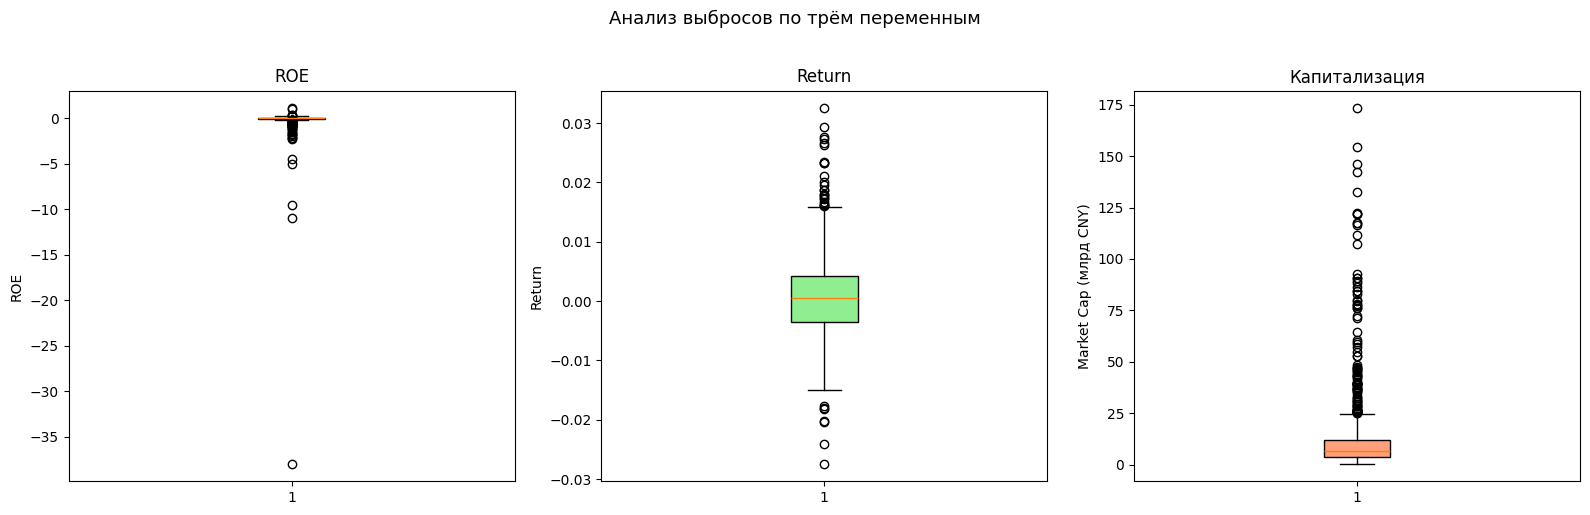

In [ ]:

# функция для расчёта границ выбросов методом IQR
# выброс: значение < Q1 - 1.5*IQR  или  > Q3 + 1.5*IQR
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

roe_low,  roe_high  = iqr_bounds(panel['ROE'].dropna())
ret_low,  ret_high  = iqr_bounds(panel['Return'].dropna())
mc_low,   mc_high   = iqr_bounds(panel['MarketCap'].dropna())

# таблицы с выбросами по каждой переменной
outliers_roe = panel[(panel['ROE']       < roe_low)  | (panel['ROE']       > roe_high)]
outliers_ret = panel[(panel['Return']    < ret_low)  | (panel['Return']    > ret_high)]
outliers_mc  = panel[(panel['MarketCap'] < mc_low)   | (panel['MarketCap'] > mc_high)]

print("Выбросы ROE")
print(f"Границы: [{roe_low:.4f}, {roe_high:.4f}] | Выбросов: {len(outliers_roe)} из {len(panel.dropna(subset=['ROE']))}")
print(outliers_roe[['Year', 'Short Name', 'ROE']].head(8))

print("\nВыбросы Return")
print(f"Границы: [{ret_low:.4f}, {ret_high:.4f}] | Выбросов: {len(outliers_ret)} из {len(panel.dropna(subset=['Return']))}")
print(outliers_ret[['Year', 'Short Name', 'Return']].head(8))

print("\nВыбросы по капитализации")
print(f"Границы: [{mc_low:.0f}, {mc_high:.0f}] | Выбросов: {len(outliers_mc)} из {len(panel.dropna(subset=['MarketCap']))}")
print(outliers_mc[['Year', 'Short Name', 'MarketCap']].head(8))

# графически: три боксплота — ROE, Return и рыночная капитализация
# точки за "усами" — это и есть выбросы
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].boxplot(panel['ROE'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('ROE')
axes[0].set_ylabel('ROE')

axes[1].boxplot(panel['Return'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Return')
axes[1].set_ylabel('Return')

axes[2].boxplot(panel['MarketCap'].dropna() / 1e9, patch_artist=True,
                boxprops=dict(facecolor='lightsalmon'))
axes[2].set_title('Капитализация')
axes[2].set_ylabel('Market Cap (млрд CNY)')

plt.suptitle('Анализ выбросов по трём переменным', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Рассмотрим результаты:

**ROE:** у 108 компаний аномально низкие значения (до –38). Такие значения характерны для компаний которые понесли разовые огромные убытки. Медиана находится чуть ниже нуля. Можем предположить, что больше половины китайских IT-компаний в период 2021–2025 были убыточны. Такие выбросы удалили, чтобы они не искажали регрессию.

**Return:** Выбросов меньше (31 из 1105). Границы нормы очень узкие: от -1.52% до +1.59% в неделю, что говорит о низкой волатильности рынка в среднем.

**Капитализация:** распределение сильно неравномерное — несколько гигантов (IFLYTEK, HUNDSUN, 360) на порядки крупнее большинства. Выбросы по капитализации не удаляли. В дальнейшем сделали взвешивание


Remove the outliers

In [ ]:
# оставляем только строки, где оба показателя в пределах нормы
panel_clean = panel[
    (panel['ROE']    >= roe_low)  & (panel['ROE']    <= roe_high) &
    (panel['Return'] >= ret_low)  & (panel['Return'] <= ret_high)
].copy()

print(f"\nСтрок до удаления выбросов: {len(panel)}")
print(f"Строк после удаления выбросов: {len(panel_clean)}")


Строк до удаления выбросов: 1105
Строк после удаления выбросов: 970


In [ ]:
panel_clean.head()

,Year,Short Name,ROE,Return,MarketCap
0,2021,360 SECURITY TECHNOLOGY INC.,0.079236,-0.004060,90889019865.840012
1,2021,ABT NETWORKS,0.043510,0.000802,3183818580.000000
2,2021,ADTEC,0.139444,0.000083,4049225784.660000
3,2021,AMARSOFT,0.119305,-0.002792,2391525360.000000
4,2021,APEX,0.091642,0.002785,6136154224.400001


Weight each company returns and financial statement variable by market capitalization

Remove empty cell values for both tables (**Hint: pqr.align**)

In [ ]:
# считаем вес каждой компании = её капитализация / сумма кап всех компаний за этот год
panel_clean['weight'] = panel_clean.groupby('Year')['MarketCap'].transform(lambda x: x / x.sum())

# взвешиваем ROE и Return — умножаем на вес
panel_clean['ROE_w']    = panel_clean['ROE']    * panel_clean['weight']
panel_clean['Return_w'] = panel_clean['Return'] * panel_clean['weight']

# переводим обратно в pivot-формат (строки=год, столбцы=компания)
# это нужно для align() — он выравнивает два DataFrame по индексу и колонкам
pqr_roe = panel_clean.pivot(index='Year', columns='Short Name', values='ROE_w')
pqr_ret = panel_clean.pivot(index='Year', columns='Short Name', values='Return_w')

# align() оставляет только общие строки и столбцы, пустые ячейки заполняет NaN
pqr_roe, pqr_ret = pqr_roe.align(pqr_ret, join='inner')

# удаляем столбцы и строки, где есть NaN
pqr_roe = pqr_roe.dropna(axis=1)
pqr_ret = pqr_ret.dropna(axis=1)

# оставляем только общие компании после dropna
common = pqr_roe.columns.intersection(pqr_ret.columns)
pqr_roe = pqr_roe[common]
pqr_ret = pqr_ret[common]

print(f"\nРазмер таблиц после align и dropna: {pqr_roe.shape}")

# собираем итоговую панель для регрессий
roe_s = pqr_roe.stack().reset_index()
roe_s.columns = ['Year', 'Short Name', 'ROE_w']
ret_s = pqr_ret.stack().reset_index()
ret_s.columns = ['Year', 'Short Name', 'Return_w']
panel_final = pd.merge(ret_s, roe_s, on=['Year', 'Short Name'])


Размер таблиц после align и dropna: (5, 146)


In [ ]:
panel_final.head()

,Year,Short Name,Return_w,ROE_w
0,2021,360 SECURITY TECHNOLOGY INC.,-0.000152,0.002972
1,2021,ABT NETWORKS,0.000001,0.000057
2,2021,ADTEC,0.000000,0.000233
3,2021,APEX,0.000007,0.000232
4,2021,ARCSOFT,-0.000065,0.000689


Теперь делаем все то же самое с таблицами по невзвешенным показателям

In [ ]:
# переводим обратно в pivot-формат (строки=год, столбцы=компания)
# это нужно для align() — он выравнивает два DataFrame по индексу и колонкам
pqr_roe1 = panel_clean.pivot(index='Year', columns='Short Name', values='ROE')
pqr_ret1 = panel_clean.pivot(index='Year', columns='Short Name', values='Return')

# align() оставляет только общие строки и столбцы, пустые ячейки заполняет NaN
pqr_roe1, pqr_ret1 = pqr_roe1.align(pqr_ret1, join='inner')

# удаляем столбцы и строки, где есть NaN
pqr_roe1 = pqr_roe1.dropna(axis=1)
pqr_ret1 = pqr_ret1.dropna(axis=1)

# оставляем только общие компании после dropna
common = pqr_roe1.columns.intersection(pqr_ret1.columns)
pqr_roe1 = pqr_roe1[common]
pqr_ret1 = pqr_ret1[common]

print(f"\nРазмер таблиц после align и dropna: {pqr_roe1.shape}")

# собираем итоговую панель для регрессий
roe_s1 = pqr_roe1.stack().reset_index()
roe_s1.columns = ['Year', 'Short Name', 'ROE']
ret_s1 = pqr_ret1.stack().reset_index()
ret_s1.columns = ['Year', 'Short Name', 'Return']
panel_final1 = pd.merge(ret_s1, roe_s1, on=['Year', 'Short Name'])


Размер таблиц после align и dropna: (5, 146)


In [ ]:
panel_final1.head()

,Year,Short Name,Return,ROE
0,2021,360 SECURITY TECHNOLOGY INC.,-0.004060,0.079236
1,2021,ABT NETWORKS,0.000802,0.043510
2,2021,ADTEC,0.000083,0.139444
3,2021,APEX,0.002785,0.091642
4,2021,ARCSOFT,-0.008773,0.093307


Run OLS for time-series data once again. Does the results change?

Проведем анализ по очишенным но не взвешенным показателям

In [ ]:
# та же регрессия что и в Part 2, но теперь на просто очищенных данных
X = sm.add_constant(panel_final1['ROE'])
y = panel_final1['Return']
ols_new1 = sm.OLS(y, X).fit()

print("\nOLS после очистки")
print(ols_new1.summary())


OLS после очистки
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     5.438
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0200
Time:                        14:27:38   Log-Likelihood:                 2762.7
No. Observations:                 730   AIC:                            -5521.
Df Residuals:                     728   BIC:                            -5512.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000 

In [ ]:

# панельная регрессия уже очищенных и взвешенных данных
X = sm.add_constant(panel_final['ROE_w'])
y = panel_final['Return_w']
ols_new = sm.OLS(y, X).fit()

print("\nOLS после очистки и взвешивания")
print(ols_new.summary())


OLS после очистки и взвешивания
                            OLS Regression Results                            
Dep. Variable:               Return_w   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.04343
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.835
Time:                        14:27:38   Log-Likelihood:                 6228.2
No. Observations:                 730   AIC:                        -1.245e+04
Df Residuals:                     728   BIC:                        -1.244e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.765e-

**OLS по очищенным, невзвешенные данным**

По сравнению с регрессией во второй части задания, коэффициент при ROE увеличился: -0.0066 и статистически значим (t = -2.33, p = 0.020). Это означает что при росте ROE на 1 единицу средняя недельная доходность акции снижается на 0.66%. Знак отрицательный — связь обратная, что нетипично с точки зрения классической финансовой теории где высокая прибыльность должна привлекать инвесторов и повышать цену акций.




**OLS после очистки и взвешивания (взвешенные по капитализации)**

Коэффициент при ROE_w равен -0.0004 и статистически незначим (t = -0.21, p = 0.835). После взвешивания по рыночной капитализации связь между ROE и доходностью полностью исчезает. R-квадрат = 0.000 — модель не объясняет ничего.

Это принципиально важный результат. Когда каждая компания получает вес пропорциональный своей капитализации, крупные игроки (IFLYTEK, HUNDSUN, BAOSIGHT) начинают доминировать в анализе.
Значимость в невзвешенной регрессии создавалась именно мелкими компаниями, у которых связь ROE с доходностью была сильнее, но которые имеют незначительный вес на реальном рынке.

Также стоит обратить внимание на Kurtosis = 27.7 и JB = 18593 во взвешенной регрессии, взвешенная модель плохо подходит для OLS

Run the Fama-Macbeth regression for the same data in two tables. Show coefficient and t-statistics. Why exactly do results differ from the panel regression?

In [ ]:

# РЕГРЕССИЯ ФАМА-МАКБЕТА

# Метод FM:
# кросс-секционная OLS отдельно для каждого года
# среднее коэффициентов по всем годам
#t-статистика = среднее / (стд / sqrt(T))

years = sorted(panel_final['Year'].unique())
coefs = []

for year in years:
    data_y = panel_final[panel_final['Year'] == year].dropna()
    if len(data_y) < 5:
        continue
    X_y = sm.add_constant(data_y['ROE_w'])
    y_y = data_y['Return_w']
    res = sm.OLS(y_y, X_y).fit()
    coefs.append({'Year': year, 'const': res.params['const'], 'ROE_w': res.params['ROE_w']})

coefs_df = pd.DataFrame(coefs).set_index('Year')
print("\nКоэффициенты по годам (FM)")
print(coefs_df)

T = len(coefs_df)
fm_mean  = coefs_df.mean()
fm_std   = coefs_df.std()
fm_tstat = fm_mean / (fm_std / np.sqrt(T))

print("\nРегрессия Фама-Макбета")
print(pd.DataFrame({'Коэффициент': fm_mean, 't-статистика': fm_tstat}))




Коэффициенты по годам (FM)
         const     ROE_w
Year                    
2021  0.000006 -0.008713
2022 -0.000014 -0.008401
2023  0.000008  0.020859
2024  0.000011 -0.011739
2025  0.000012 -0.001306

Регрессия Фама-Макбета
       Коэффициент  t-статистика
const     0.000005      0.938739
ROE_w    -0.001860     -0.313573


Run the FM-reg for the COVID-19 pandemic period

In [ ]:

# РЕГРЕССИЯ ФАМА-МАКБЕТА

# Метод FM:

years = sorted(panel_final1['Year'].unique())
coefs = []

for year in years:
    data_y = panel_final1[panel_final1['Year'] == year].dropna()
    if len(data_y) < 5:
        continue
    X_y = sm.add_constant(data_y['ROE'])
    y_y = data_y['Return']
    res = sm.OLS(y_y, X_y).fit()
    coefs.append({'Year': year, 'const': res.params['const'], 'ROE': res.params['ROE']})

coefs_df1 = pd.DataFrame(coefs).set_index('Year')
print("\n Коэффициенты по годам (FM)")
print(coefs_df1)

T = len(coefs_df1)
fm_mean  = coefs_df1.mean()
fm_std   = coefs_df1.std()
fm_tstat = fm_mean / (fm_std / np.sqrt(T))

print("\n Регрессия Фама-Макбета")
print(pd.DataFrame({'Коэффициент': fm_mean, 't-статистика': fm_tstat}))




 Коэффициенты по годам (FM)
         const       ROE
Year                    
2021  0.001079 -0.003874
2022 -0.003712 -0.003493
2023  0.002997 -0.003603
2024  0.000804  0.006439
2025  0.002356 -0.003024

 Регрессия Фама-Макбета
       Коэффициент  t-статистика
const     0.000705      0.599544
ROE      -0.001511     -0.758489


По результатам регрессий Фама-Макбета можно сделать вывод об отсутствии статистически значимой связи между ROE и доходностью акций китайских IT-компаний в период 2021–2025: коэффициент при ROE незначим как во взвешенной (-0.0019, t = -0.31), так и в невзвешенной (-0.0015, t = -0.76) модели.

При этом коэффициенты по отдельным годам нестабильны и меняют знак — в 2023 году взвешенная модель даёт положительный коэффициент (+0.021), что отражает частичное восстановление рынка после пика регуляторного давления. Нашей команда сделала вывод: OLS объединяет все наблюдения в одну регрессию и завышает значимость за счёт повторяющейся структуры данных, тогда как FM усредняет независимые годовые оценки, давая каждому году одинаковый вес и устраняя влияние временной корреляции остатков.

FM: COVID [2021, 2022], наблюдений: 292

 FM-регрессия COVID-19
       Коэффициент  t-статистика
const    -0.000004     -0.410746
ROE_w    -0.008557    -54.771168


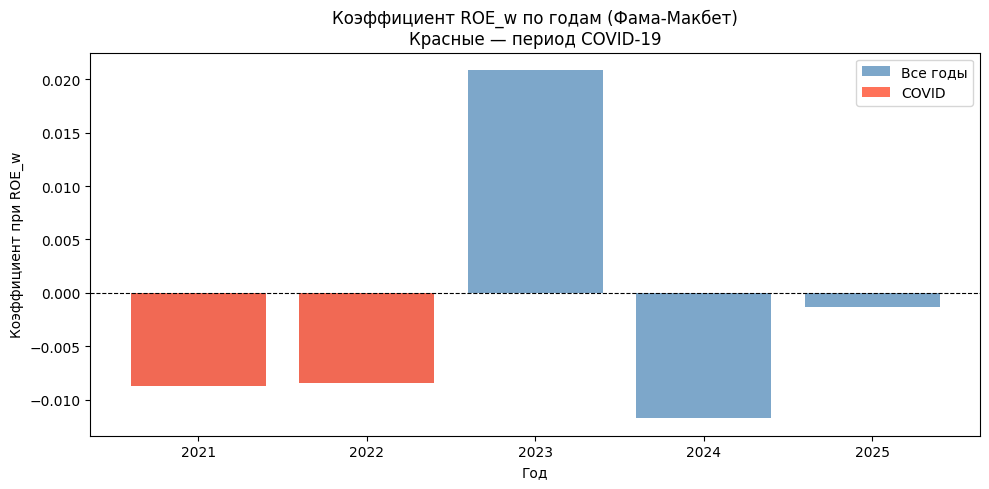

In [ ]:

# FM-РЕГРЕССИЯ ДЛЯ ПЕРИОДА COVID-19 (2020–2021)
# в нашей панели данные начинаются с 2021 (ROE сдвинут +1)
# поэтому COVID период = 2021 и 2022
covid_years = [2021, 2022]
panel_covid = panel_final[panel_final['Year'].isin(covid_years)].dropna()

print(f"FM: COVID {covid_years}, наблюдений: {len(panel_covid)}")

coefs_covid = []
for year in covid_years:
    data_y = panel_covid[panel_covid['Year'] == year].dropna()
    if len(data_y) < 5:
        continue
    X_y = sm.add_constant(data_y['ROE_w'])
    y_y = data_y['Return_w']
    res = sm.OLS(y_y, X_y).fit()
    coefs_covid.append({'Year': year, 'const': res.params['const'], 'ROE_w': res.params['ROE_w']})

coefs_covid_df = pd.DataFrame(coefs_covid).set_index('Year')

T_c = len(coefs_covid_df)
fm_mean_c  = coefs_covid_df.mean()
fm_std_c   = coefs_covid_df.std()
fm_tstat_c = fm_mean_c / (fm_std_c / np.sqrt(T_c))

print("\n FM-регрессия COVID-19")
print(pd.DataFrame({'Коэффициент': fm_mean_c, 't-статистика': fm_tstat_c}))

# сравниваем коэффициент ROE_w: весь период vs COVID
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(coefs_df.index, coefs_df['ROE_w'], color='steelblue', alpha=0.7, label='Все годы')
for y in covid_years:
    if y in coefs_df.index:
        ax.bar(y, coefs_df.loc[y, 'ROE_w'], color='tomato', alpha=0.9,
               label='COVID' if y == covid_years[0] else '')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Коэффициент ROE_w по годам (Фама-Макбет)\nКрасные — период COVID-19')
ax.set_xlabel('Год')
ax.set_ylabel('Коэффициент при ROE_w')
ax.legend()
plt.tight_layout()
plt.show()

Коэффициент при ROE_w в период COVID равен -0.0086 при t-статистике -54.77 — результат  значим.

График показывает нестабильность коэффициента во времени. В 2021–2022 (красные столбики, COVID) коэффициент отрицательный и примерно одинаковый по величине, что говорит о устойчивом поведении инвесторов в кризисный период.

В 2023 году коэффициент станосится положительным, ввиду восстановления экномики (+0,02). В  2023 году инвесторы начали позитивно реагировать на высокий ROE, то есть рынок вернулся к классическому поведению. Резкий перелом происходит в 2024 году — коэффициент снова стоновится отрицательным. Это происходит на фоне финансового кризиса в Китае, что провоцирует отрицательную доходность ценных бумаг. В 2025 рынок постепенно восттанавливается.

# Выводы:


В ходе исследования была проверена связь между ROE и доходностью акций IT-компаний китайского рынка за 2021–2025 годы.  OLS на невзвешенных данных показала значимый отрицательный коэффициент при ROE, однако после взвешивания по рыночной капитализации и применения регрессии Фама-Макбета связь оказалась статистически незначимой.

Это означает что наблюдаемая в OLS зависимость была следствием равного веса мелких и крупных компаний, а не реальной рыночной закономерностью. Исключением стал период COVID-19 (2021–2022), когда коэффициент резко усилился и стал значимым — инвесторы в условиях неопределённости игнорировали фундаментальные показатели и руководствовались иными мотивами. В целом гипотеза о положительной связи ROE и доходности акций для данной выборки не подтверждается: поведение китайского IT-рынка в этот период определялось макроэкономическими и регуляторными факторами в значительно большей степени, чем показателями финансовой отчётности.